In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, time, json, math, random
from pathlib import Path

PROJECT_NAME = "CSE499B_Lightweight_Diffusion"
ROOT = Path("/content/drive/MyDrive")/PROJECT_NAME
CKPT_DIR = ROOT/"checkpoints"
SAMPLE_DIR = ROOT/"samples"
RESULT_DIR = ROOT/"results"
CONFIG_DIR = ROOT/"configs"

for d in [CKPT_DIR, SAMPLE_DIR, RESULT_DIR, CONFIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Project root:", ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root: /content/drive/MyDrive/CSE499B_Lightweight_Diffusion


In [2]:
# !pip -q install torchmetrics torchvision tqdm einops
!pip -q install torchmetrics torchvision tqdm einops torch-fidelity

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils
from tqdm import tqdm
from einops import rearrange

def seed_all(seed=42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_all(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [4]:
BASE_CONFIG = {
    "dataset": "CIFAR10",      # MNIST / FashionMNIST / CIFAR10
    "image_size": 32,
    "channels": 3,
    "batch_size": 128,
    "num_workers": 2,

    "T": 1000,                 # diffusion steps for training
    "beta_start": 1e-4,
    "beta_end": 0.02,

    "epochs": 30,              # increase for final runs (e.g., 50-200)
    "lr": 2e-4,

    "model": {
        "base_channels": 128,  # baseline width
        "channel_mults": [1,2,2,2],  # depth/stages
        "use_attn": True,
        "use_depthwise": False,
        "width_mult": 1.0,     # lightweight width scaling
    },

    "ema": {"use": True, "decay": 0.999},

    "sample": {
        "n_samples": 64,
        "grid_rows": 8,
        "ddim_steps": 50,       # for fast sampling
        "ddim_eta": 0.0
    }
}

def save_config(cfg, name):
    path = CONFIG_DIR/f"{name}.json"
    with open(path, "w") as f:
        json.dump(cfg, f, indent=2)
    return path

In [5]:
import copy

EXPERIMENTS = {
  "baseline": copy.deepcopy(BASE_CONFIG),

  "width_half": copy.deepcopy(BASE_CONFIG),
  "depth_reduce": copy.deepcopy(BASE_CONFIG),
  "depthwise_conv": copy.deepcopy(BASE_CONFIG),
  "no_attn": copy.deepcopy(BASE_CONFIG),

  "best_combo": copy.deepcopy(BASE_CONFIG),
}

EXPERIMENTS["width_half"]["model"]["width_mult"] = 0.5
EXPERIMENTS["depth_reduce"]["model"]["channel_mults"] = [1,2,2]    # fewer stages
EXPERIMENTS["depthwise_conv"]["model"]["use_depthwise"] = True
EXPERIMENTS["no_attn"]["model"]["use_attn"] = False

EXPERIMENTS["best_combo"]["model"]["width_mult"] = 0.5
EXPERIMENTS["best_combo"]["model"]["channel_mults"] = [1,2,2]
EXPERIMENTS["best_combo"]["model"]["use_depthwise"] = True
EXPERIMENTS["best_combo"]["model"]["use_attn"] = False

for k in EXPERIMENTS:
    save_config(EXPERIMENTS[k], k)

list(EXPERIMENTS.keys())

['baseline',
 'width_half',
 'depth_reduce',
 'depthwise_conv',
 'no_attn',
 'best_combo']

In [6]:
# Dataset Loader
def get_dataloaders(cfg):
    ds = cfg["dataset"]
    img_size = cfg["image_size"]
    bs = cfg["batch_size"]

    if ds in ["MNIST", "FashionMNIST"]:
        channels = 1
        tfm = transforms.Compose([
            transforms.Resize(img_size),
            transforms.ToTensor(),
            transforms.Lambda(lambda x: x*2 - 1)  # [-1,1]
        ])
        DatasetCls = datasets.MNIST if ds == "MNIST" else datasets.FashionMNIST
        trainset = DatasetCls(root="/content/data", train=True, download=True, transform=tfm)
    elif ds == "CIFAR10":
        channels = 3
        tfm = transforms.Compose([
            transforms.Resize(img_size),
            transforms.ToTensor(),
            transforms.Lambda(lambda x: x*2 - 1)
        ])
        trainset = datasets.CIFAR10(root="/content/data", train=True, download=True, transform=tfm)
    else:
        raise ValueError("Unknown dataset")

    loader = DataLoader(trainset, batch_size=bs, shuffle=True,
                        num_workers=cfg["num_workers"], pin_memory=True, drop_last=True)
    return loader, channels

def denorm(x):
    # [-1,1] -> [0,1]
    return (x.clamp(-1,1) + 1) * 0.5

In [7]:
# Diffusion definitions(needed for sampling + FID)
def make_beta_schedule(T, beta_start, beta_end):
    return torch.linspace(beta_start, beta_end, T)

class Diffusion:
    def __init__(self, T=1000, beta_start=1e-4, beta_end=0.02, device="cuda"):
        self.T = T
        self.device = device
        self.betas = make_beta_schedule(T, beta_start, beta_end).to(device)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.alphas_cumprod_prev = torch.cat([torch.tensor([1.0], device=device), self.alphas_cumprod[:-1]], dim=0)

        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)

    def q_sample(self, x0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x0)
        a = self.sqrt_alphas_cumprod[t].view(-1,1,1,1)
        b = self.sqrt_one_minus_alphas_cumprod[t].view(-1,1,1,1)
        return a * x0 + b * noise, noise

def timestep_embedding(t, dim=256):
    # sinusoidal embeddings
    half = dim // 2
    freqs = torch.exp(-math.log(10000) * torch.arange(0, half, dtype=torch.float32) / half).to(t.device)
    args = t.float().unsqueeze(1) * freqs.unsqueeze(0)
    emb = torch.cat([torch.cos(args), torch.sin(args)], dim=-1)
    if dim % 2 == 1:
        emb = F.pad(emb, (0,1))
    return emb

In [8]:
# MODEL DEFINITIONS
class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, p=1):
        super().__init__()
        self.dw = nn.Conv2d(in_ch, in_ch, kernel_size=k, padding=p, groups=in_ch, bias=False)
        self.pw = nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False)
        self.bn = nn.GroupNorm(8, out_ch)
    def forward(self, x):
        return self.bn(self.pw(self.dw(x)))

def conv3x3(in_ch, out_ch, use_depthwise=False):
    if use_depthwise:
        return DepthwiseSeparableConv(in_ch, out_ch, k=3, p=1)
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
        nn.GroupNorm(8, out_ch),
    )

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, tdim, use_depthwise=False):
        super().__init__()
        self.conv1 = conv3x3(in_ch, out_ch, use_depthwise)
        self.conv2 = conv3x3(out_ch, out_ch, use_depthwise)
        self.time_mlp = nn.Sequential(nn.SiLU(), nn.Linear(tdim, out_ch))
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self.act = nn.SiLU()

    def forward(self, x, t_emb):
        h = self.act(self.conv1(x))
        h = h + self.time_mlp(t_emb).view(-1, h.shape[1], 1, 1)
        h = self.act(self.conv2(h))
        return h + self.skip(x)

class SelfAttention2d(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.norm = nn.GroupNorm(8, ch)
        self.qkv = nn.Conv2d(ch, ch*3, 1)
        self.proj = nn.Conv2d(ch, ch, 1)

    def forward(self, x):
        b,c,h,w = x.shape
        x0 = x
        x = self.norm(x)
        qkv = self.qkv(x)
        q,k,v = qkv.chunk(3, dim=1)
        q = rearrange(q, "b c h w -> b (h w) c")
        k = rearrange(k, "b c h w -> b c (h w)")
        v = rearrange(v, "b c h w -> b (h w) c")
        attn = torch.softmax((q @ k) / math.sqrt(c), dim=-1)
        out = attn @ v
        out = rearrange(out, "b (h w) c -> b c h w", h=h, w=w)
        return x0 + self.proj(out)

class UNet(nn.Module):
    def __init__(self, in_ch=3, base_ch=128, channel_mults=(1,2,2,2), use_attn=True, use_depthwise=False, tdim=256):
        super().__init__()
        self.tdim = tdim
        self.time_embed = nn.Sequential(
            nn.Linear(tdim, tdim*4), nn.SiLU(), nn.Linear(tdim*4, tdim)
        )

        chs = [base_ch*m for m in channel_mults]
        self.in_conv = nn.Conv2d(in_ch, chs[0], 3, padding=1)

        # Down
        self.downs = nn.ModuleList()
        self.attn_down = nn.ModuleList()
        inC = chs[0]
        for outC in chs:
            self.downs.append(ResBlock(inC, outC, tdim, use_depthwise))
            self.downs.append(ResBlock(outC, outC, tdim, use_depthwise))
            self.attn_down.append(SelfAttention2d(outC) if use_attn and outC >= 256 else nn.Identity())
            inC = outC
        self.downsample = nn.ModuleList([nn.Conv2d(chs[i], chs[i], 4, 2, 1) for i in range(len(chs)-1)])

        # Mid
        midC = chs[-1]
        self.mid1 = ResBlock(midC, midC, tdim, use_depthwise)
        self.mid_attn = SelfAttention2d(midC) if use_attn else nn.Identity()
        self.mid2 = ResBlock(midC, midC, tdim, use_depthwise)

        # Up
        self.upsample = nn.ModuleList([nn.ConvTranspose2d(chs[i+1], chs[i+1], 4, 2, 1) for i in range(len(chs)-1)][::-1])
        self.ups = nn.ModuleList()
        self.attn_up = nn.ModuleList()
        for i in reversed(range(len(chs))):
            outC = chs[i]
            self.ups.append(ResBlock(midC + outC, outC, tdim, use_depthwise))
            self.ups.append(ResBlock(outC, outC, tdim, use_depthwise))
            self.attn_up.append(SelfAttention2d(outC) if use_attn and outC >= 256 else nn.Identity())
            midC = outC

        self.out_norm = nn.GroupNorm(8, chs[0])
        self.out_conv = nn.Conv2d(chs[0], in_ch, 3, padding=1)

    def forward(self, x, t):
        t_emb = timestep_embedding(t, self.tdim)
        t_emb = self.time_embed(t_emb)

        h = self.in_conv(x)
        skips = []
        ds_idx = 0

        # Down path
        for i in range(len(self.attn_down)):
            h = self.downs[2*i](h, t_emb)
            h = self.downs[2*i+1](h, t_emb)
            h = self.attn_down[i](h)
            skips.append(h)
            if i < len(self.attn_down)-1:
                h = self.downsample[ds_idx](h)
                ds_idx += 1

        # Mid
        h = self.mid1(h, t_emb)
        h = self.mid_attn(h)
        h = self.mid2(h, t_emb)

        # Up path
        us_idx = 0
        for i in range(len(self.attn_up)):
            skip = skips.pop()
            h = torch.cat([h, skip], dim=1)
            h = self.ups[2*i](h, t_emb)
            h = self.ups[2*i+1](h, t_emb)
            h = self.attn_up[i](h)
            if i < len(self.attn_up)-1:
                h = self.upsample[us_idx](h)
                us_idx += 1

        h = F.silu(self.out_norm(h))
        return self.out_conv(h)

In [9]:
class EMA:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {k: v.detach().clone() for k, v in model.state_dict().items()}

    @torch.no_grad()
    def update(self, model):
        for k, v in model.state_dict().items():
            self.shadow[k].mul_(self.decay).add_(v.detach(), alpha=1 - self.decay)

    def copy_to(self, model):
        model.load_state_dict(self.shadow, strict=True)

In [10]:
@torch.no_grad()
def ddpm_sample(model, diff, shape, steps=None):
    model.eval()
    T = diff.T if steps is None else steps
    x = torch.randn(shape, device=diff.device)
    for i in tqdm(reversed(range(T)), total=T, desc="DDPM sampling"):
        t = torch.full((shape[0],), i, device=diff.device, dtype=torch.long)
        eps = model(x, t)

        beta = diff.betas[i]
        alpha = diff.alphas[i]
        alpha_bar = diff.alphas_cumprod[i]

        # x0 pred
        x0 = (x - torch.sqrt(1 - alpha_bar) * eps) / torch.sqrt(alpha_bar)

        if i > 0:
            noise = torch.randn_like(x)
        else:
            noise = torch.zeros_like(x)

        x = (1/torch.sqrt(alpha))*(x - (beta/torch.sqrt(1-alpha_bar))*eps) + torch.sqrt(beta)*noise
    return x

@torch.no_grad()
def ddim_sample(model, diff, shape, ddim_steps=50, eta=0.0):
    model.eval()
    x = torch.randn(shape, device=diff.device)

    # choose timesteps
    times = torch.linspace(0, diff.T-1, ddim_steps, device=diff.device).long()
    times = list(reversed(times.tolist()))

    for idx, i in enumerate(tqdm(times, desc="DDIM sampling")):
        t = torch.full((shape[0],), i, device=diff.device, dtype=torch.long)
        eps = model(x, t)

        alpha_bar = diff.alphas_cumprod[i]
        x0 = (x - torch.sqrt(1 - alpha_bar) * eps) / torch.sqrt(alpha_bar)

        if idx == len(times)-1:
            x = x0
            break

        j = times[idx+1]
        alpha_bar_next = diff.alphas_cumprod[j]

        sigma = eta * torch.sqrt((1-alpha_bar_next)/(1-alpha_bar)) * torch.sqrt(1 - alpha_bar/alpha_bar_next)
        noise = torch.randn_like(x) if sigma > 0 else 0.0

        x = torch.sqrt(alpha_bar_next)*x0 + torch.sqrt(1-alpha_bar_next - sigma**2)*eps + sigma*noise

    return x

In [11]:
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def save_ckpt(path, model, opt, epoch, ema=None, cfg=None):
    payload = {
        "model": model.state_dict(),
        "opt": opt.state_dict(),
        "epoch": epoch,
    }
    if ema is not None:
        payload["ema"] = ema.shadow
    if cfg is not None:
        payload["cfg"] = cfg
    torch.save(payload, path)

def train_one_experiment(exp_name, cfg):
    loader, channels = get_dataloaders(cfg)
    cfg["channels"] = channels

    mcfg = cfg["model"]
    base_ch = int(mcfg["base_channels"] * mcfg["width_mult"])
    model = UNet(
        in_ch=channels,
        base_ch=base_ch,
        channel_mults=tuple(mcfg["channel_mults"]),
        use_attn=mcfg["use_attn"],
        use_depthwise=mcfg["use_depthwise"],
        tdim=256
    ).to(device)

    diff = Diffusion(cfg["T"], cfg["beta_start"], cfg["beta_end"], device=device)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg["lr"])

    ema = None
    if cfg["ema"]["use"]:
        ema = EMA(model, decay=cfg["ema"]["decay"])

    print(f"[{exp_name}] Params: {count_params(model)/1e6:.2f}M")
    model.train()

    log = []
    for epoch in range(1, cfg["epochs"]+1):
        torch.cuda.reset_peak_memory_stats()
        t0 = time.time()
        pbar = tqdm(loader, desc=f"{exp_name} | epoch {epoch}/{cfg['epochs']}")
        avg_loss = 0.0

        for x, _ in pbar:
            x = x.to(device)
            b = x.size(0)
            t = torch.randint(0, diff.T, (b,), device=device).long()

            xt, noise = diff.q_sample(x, t)
            pred = model(xt, t)

            loss = F.mse_loss(pred, noise)

            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()

            if ema is not None:
                ema.update(model)

            avg_loss = 0.99*avg_loss + 0.01*loss.item() if avg_loss != 0 else loss.item()
            pbar.set_postfix(loss=avg_loss)

        epoch_time = time.time() - t0
        peak_mem = torch.cuda.max_memory_allocated()/1024**2 if device=="cuda" else 0.0

        # Save checkpoint
        ckpt_path = CKPT_DIR/f"{exp_name}_epoch{epoch}.pt"
        save_ckpt(ckpt_path, model, opt, epoch, ema=ema, cfg=cfg)

        log.append({
            "exp": exp_name,
            "epoch": epoch,
            "loss": float(avg_loss),
            "epoch_time_sec": float(epoch_time),
            "peak_mem_mb": float(peak_mem),
            "params_m": float(count_params(model)/1e6),
        })

        # Quick samples each few epochs
        if epoch == 1 or epoch % max(1, cfg["epochs"]//5) == 0:
            sampler_model = UNet(
                in_ch=channels,
                base_ch=base_ch,
                channel_mults=tuple(mcfg["channel_mults"]),
                use_attn=mcfg["use_attn"],
                use_depthwise=mcfg["use_depthwise"],
                tdim=256
            ).to(device)
            if ema is not None:
                ema.copy_to(sampler_model)
            else:
                sampler_model.load_state_dict(model.state_dict())

            n = cfg["sample"]["n_samples"]
            shape = (n, channels, cfg["image_size"], cfg["image_size"])
            samples = ddim_sample(sampler_model, diff, shape,
                                  ddim_steps=cfg["sample"]["ddim_steps"],
                                  eta=cfg["sample"]["ddim_eta"])
            grid = utils.make_grid(denorm(samples), nrow=cfg["sample"]["grid_rows"])
            out_path = SAMPLE_DIR/f"{exp_name}_epoch{epoch}_ddim.png"
            utils.save_image(grid, out_path)
            print("Saved samples:", out_path)

    # Save logs
    log_path = RESULT_DIR/f"{exp_name}_trainlog.json"
    with open(log_path, "w") as f:
        json.dump(log, f, indent=2)
    print("Saved log:", log_path)

    return model, ema, diff, cfg

In [12]:
from torchmetrics.image.fid import FrechetInceptionDistance

@torch.no_grad()
def compute_fid(cfg, model, ema, diff, n_real=5000, n_fake=5000, use_ddim=True):
    loader, channels = get_dataloaders(cfg)
    fid = FrechetInceptionDistance(feature=2048).to(device)

    # Build sampler model (EMA)
    mcfg = cfg["model"]
    base_ch = int(mcfg["base_channels"] * mcfg["width_mult"])
    sampler_model = UNet(
        in_ch=channels,
        base_ch=base_ch,
        channel_mults=tuple(mcfg["channel_mults"]),
        use_attn=mcfg["use_attn"],
        use_depthwise=mcfg["use_depthwise"],
        tdim=256
    ).to(device)

    if ema is not None:
        ema.copy_to(sampler_model)
    else:
        sampler_model.load_state_dict(model.state_dict())
    sampler_model.eval()

    # Real images
    seen = 0
    for x, _ in loader:
        x = x.to(device)
        x01 = (denorm(x)*255).clamp(0,255).to(torch.uint8)
        fid.update(x01, real=True)
        seen += x.size(0)
        if seen >= n_real:
            break

    # Fake images
    bs = cfg["batch_size"]
    made = 0
    while made < n_fake:
        cur = min(bs, n_fake - made)
        shape = (cur, channels, cfg["image_size"], cfg["image_size"])
        if use_ddim:
            fake = ddim_sample(sampler_model, diff, shape,
                               ddim_steps=cfg["sample"]["ddim_steps"],
                               eta=cfg["sample"]["ddim_eta"])
        else:
            fake = ddpm_sample(sampler_model, diff, shape, steps=diff.T)
        fake01 = (denorm(fake)*255).clamp(0,255).to(torch.uint8)
        fid.update(fake01, real=False)
        made += cur

    score = fid.compute().item()
    return score

In [13]:
@torch.no_grad()
def benchmark_sampling(cfg, model, ema, diff, n_images=64, repeats=3, use_ddim=True):
    loader, channels = get_dataloaders(cfg)

    mcfg = cfg["model"]
    base_ch = int(mcfg["base_channels"] * mcfg["width_mult"])
    sampler_model = UNet(
        in_ch=channels,
        base_ch=base_ch,
        channel_mults=tuple(mcfg["channel_mults"]),
        use_attn=mcfg["use_attn"],
        use_depthwise=mcfg["use_depthwise"],
        tdim=256
    ).to(device)

    if ema is not None:
        ema.copy_to(sampler_model)
    else:
        sampler_model.load_state_dict(model.state_dict())
    sampler_model.eval()

    shape = (n_images, channels, cfg["image_size"], cfg["image_size"])

    # warmup
    _ = ddim_sample(sampler_model, diff, shape, cfg["sample"]["ddim_steps"], cfg["sample"]["ddim_eta"]) if use_ddim else ddpm_sample(sampler_model, diff, shape)

    times = []
    for _ in range(repeats):
        torch.cuda.synchronize()
        t0 = time.time()
        _ = ddim_sample(sampler_model, diff, shape, cfg["sample"]["ddim_steps"], cfg["sample"]["ddim_eta"]) if use_ddim else ddpm_sample(sampler_model, diff, shape)
        torch.cuda.synchronize()
        times.append(time.time() - t0)

    sec_per_img = (sum(times)/len(times)) / n_images
    return sec_per_img

In [14]:
# Example: run one experiment
exp_name = "baseline"
cfg = EXPERIMENTS[exp_name]

# Optional quick debug: use MNIST first
# cfg["dataset"] = "MNIST"; cfg["image_size"]=32; cfg["epochs"]=5; cfg["batch_size"]=256

model, ema, diff, cfg_used = train_one_experiment(exp_name, cfg)

100%|██████████| 170M/170M [00:14<00:00, 12.0MB/s]


[baseline] Params: 28.89M


baseline | epoch 1/30: 100%|██████████| 390/390 [00:32<00:00, 12.05it/s, loss=0.0714]
DDIM sampling:  98%|█████████▊| 49/50 [00:00<00:00, 50.68it/s]


Saved samples: /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/samples/baseline_epoch1_ddim.png


baseline | epoch 2/30: 100%|██████████| 390/390 [00:30<00:00, 12.69it/s, loss=0.0398]
baseline | epoch 3/30: 100%|██████████| 390/390 [00:30<00:00, 12.74it/s, loss=0.0378]
baseline | epoch 4/30: 100%|██████████| 390/390 [00:30<00:00, 12.61it/s, loss=0.0355]
baseline | epoch 5/30: 100%|██████████| 390/390 [00:30<00:00, 12.73it/s, loss=0.0348]
baseline | epoch 6/30: 100%|██████████| 390/390 [00:30<00:00, 12.74it/s, loss=0.0345]
DDIM sampling:  98%|█████████▊| 49/50 [00:00<00:00, 58.78it/s]


...

Saved samples: /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/samples/baseline_epoch18_ddim.png


baseline | epoch 19/30: 100%|██████████| 390/390 [00:30<00:00, 12.73it/s, loss=0.0319]
baseline | epoch 20/30: 100%|██████████| 390/390 [00:30<00:00, 12.70it/s, loss=0.0321]
baseline | epoch 21/30: 100%|██████████| 390/390 [00:30<00:00, 12.74it/s, loss=0.0312]
baseline | epoch 22/30: 100%|██████████| 390/390 [00:30<00:00, 12.68it/s, loss=0.0316]
baseline | epoch 23/30: 100%|██████████| 390/390 [00:30<00:00, 12.67it/s, loss=0.0319]
baseline | epoch 24/30: 100%|██████████| 390/390 [00:31<00:00, 12.54it/s, loss=0.0314]
DDIM sampling:  98%|█████████▊| 49/50 [00:00<00:00, 58.36it/s]


Saved samples: /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/samples/baseline_epoch24_ddim.png


baseline | epoch 25/30: 100%|██████████| 390/390 [00:30<00:00, 12.71it/s, loss=0.0314]
baseline | epoch 26/30: 100%|██████████| 390/390 [00:30<00:00, 12.66it/s, loss=0.0318]
baseline | epoch 27/30: 100%|██████████| 390/390 [00:30<00:00, 12.63it/s, loss=0.0308]
baseline | epoch 28/30: 100%|██████████| 390/390 [00:30<00:00, 12.60it/s, loss=0.0309]
baseline | epoch 29/30: 100%|██████████| 390/390 [00:31<00:00, 12.58it/s, loss=0.0312]
baseline | epoch 30/30: 100%|██████████| 390/390 [00:30<00:00, 12.71it/s, loss=0.0316]
DDIM sampling:  98%|█████████▊| 49/50 [00:00<00:00, 59.21it/s]


Saved samples: /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/samples/baseline_epoch30_ddim.png
Saved log: /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/results/baseline_trainlog.json


In [14]:
# Load last baseline checkpoint
exp_name = "baseline"
last_epoch = EXPERIMENTS[exp_name]["epochs"]

ckpt_path = CKPT_DIR/f"{exp_name}_epoch{last_epoch}.pt"
print("Loading from:", ckpt_path)

ckpt = torch.load(ckpt_path, map_location=device)

cfg_used = ckpt["cfg"]

# Rebuild model
mcfg = cfg_used["model"]
base_ch = int(mcfg["base_channels"] * mcfg["width_mult"])

model = UNet(
    in_ch=cfg_used["channels"],
    base_ch=base_ch,
    channel_mults=tuple(mcfg["channel_mults"]),
    use_attn=mcfg["use_attn"],
    use_depthwise=mcfg["use_depthwise"],
    tdim=256
).to(device)

model.load_state_dict(ckpt["model"])

# Rebuild EMA
ema = EMA(model, decay=cfg_used["ema"]["decay"])
ema.shadow = ckpt["ema"]

# Recreate diffusion object
diff = Diffusion(cfg_used["T"], cfg_used["beta_start"], cfg_used["beta_end"], device=device)

print("Model successfully restored.")

Loading from: /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/checkpoints/baseline_epoch30.pt
Model successfully restored.


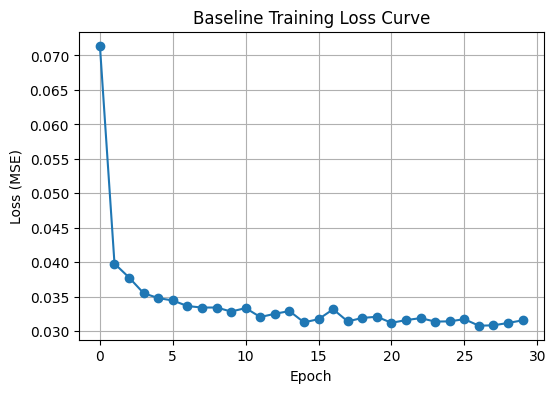

First epoch loss: 0.07141799268781636
Last epoch loss : 0.031586179995252046


In [15]:
import matplotlib.pyplot as plt
import json

log_path = RESULT_DIR/"baseline_trainlog.json"

with open(log_path) as f:
    logs = json.load(f)

losses = [x["loss"] for x in logs]

plt.figure(figsize=(6,4))
plt.plot(losses, marker="o")
plt.title("Baseline Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.grid(True)
plt.show()

print("First epoch loss:", losses[0])
print("Last epoch loss :", losses[-1])

Early sample: /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/samples/baseline_epoch1_ddim.png
Late sample : /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/samples/baseline_epoch30_ddim.png


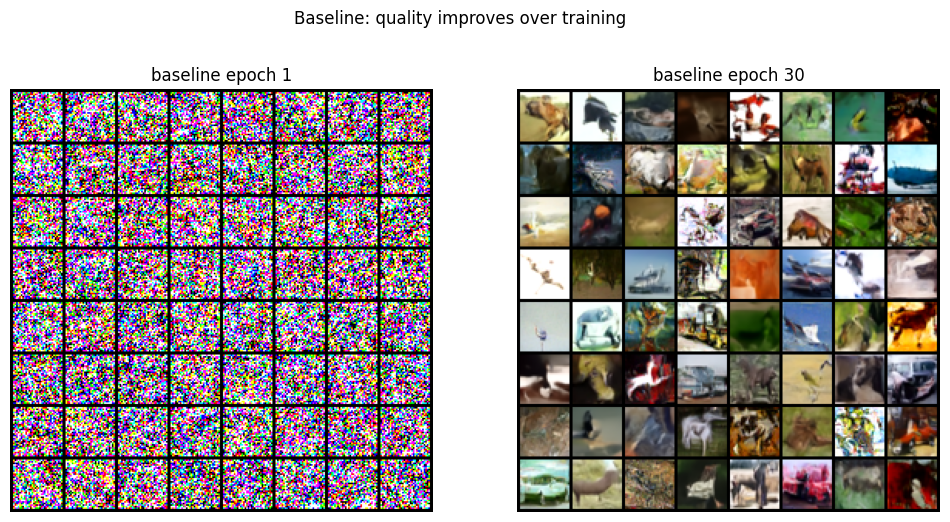

In [16]:
from PIL import Image
import matplotlib.pyplot as plt

def show_side_by_side(img_path_left, img_path_right, title_left="Left", title_right="Right", suptitle="Comparison"):
    imgL = Image.open(img_path_left)
    imgR = Image.open(img_path_right)

    plt.figure(figsize=(12,6))
    plt.subplot(1,2,1)
    plt.imshow(imgL)
    plt.axis("off")
    plt.title(title_left)

    plt.subplot(1,2,2)
    plt.imshow(imgR)
    plt.axis("off")
    plt.title(title_right)

    plt.suptitle(suptitle)
    plt.show()

exp = "baseline"
early_epoch = 1
late_epoch = cfg_used["epochs"]  # last epoch actually trained

img_early = SAMPLE_DIR/f"{exp}_epoch{early_epoch}_ddim.png"
img_late  = SAMPLE_DIR/f"{exp}_epoch{late_epoch}_ddim.png"

print("Early sample:", img_early)
print("Late sample :", img_late)

show_side_by_side(
    img_early, img_late,
    title_left=f"{exp} epoch {early_epoch}",
    title_right=f"{exp} epoch {late_epoch}",
    suptitle="Baseline: quality improves over training"
)

In [19]:
baseline_fid = compute_fid(cfg_used, model, ema, diff, n_real=2000, n_fake=2000, use_ddim=True)
baseline_sp  = benchmark_sampling(cfg_used, model, ema, diff, n_images=64, repeats=3, use_ddim=True)

baseline_result = {
    "exp": "baseline",
    "dataset": cfg_used["dataset"],
    "params_m": count_params(model)/1e6,
    "fid_ddim": baseline_fid,
    "sec_per_img_ddim": baseline_sp,
    "ddim_steps": cfg_used["sample"]["ddim_steps"]
}

print(baseline_result)

out_path = RESULT_DIR/"baseline_eval.json"
with open(out_path, "w") as f:
    json.dump(baseline_result, f, indent=2)

print("Saved:", out_path)

DDIM sampling:  98%|█████████▊| 49/50 [00:00<00:00, 61.86it/s]

{'exp': 'baseline', 'dataset': 'CIFAR10', 'params_m': 28.894595, 'fid_ddim': 59.760921478271484, 'sec_per_img_ddim': 0.012607882420221964, 'ddim_steps': 50}
Saved: /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/results/baseline_eval.json


For CIFAR-10:

FID	Interpretation
<10	Excellent (paper-level)
10–30	Very good
30–50	Decent
50–80	Basic / early training
>80	Poor

>>>> 59.7 means:

Model is learning

Images are meaningful

But quality is still mid-level

Likely needs more epochs

In [20]:
import pandas as pd
import json

with open(RESULT_DIR/"baseline_eval.json") as f:
    baseline_result = json.load(f)

df_base = pd.DataFrame([baseline_result])
display(df_base)

csv_path = RESULT_DIR/"baseline_eval.csv"
df_base.to_csv(csv_path, index=False)
print("Saved:", csv_path)

,exp,dataset,params_m,fid_ddim,sec_per_img_ddim,ddim_steps
0,baseline,CIFAR10,28.894595,59.760921,0.012608,50


Saved: /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/results/baseline_eval.csv


In [21]:
results = []
results.append(baseline_result)  # keep baseline first

# OPTIONAL: quick test run (uncomment for faster first try)
# for k in EXPERIMENTS:
#     EXPERIMENTS[k]["epochs"] = 10

for exp_name, cfg in EXPERIMENTS.items():
    if exp_name == "baseline":
        continue

    print("\n==============================")
    print("Running experiment:", exp_name)
    print("==============================")

    model, ema, diff, cfg_used = train_one_experiment(exp_name, cfg)

    fid = compute_fid(cfg_used, model, ema, diff, n_real=2000, n_fake=2000, use_ddim=True)
    sp  = benchmark_sampling(cfg_used, model, ema, diff, n_images=64, repeats=3, use_ddim=True)

    results.append({
        "exp": exp_name,
        "dataset": cfg_used["dataset"],
        "params_m": count_params(model)/1e6,
        "fid_ddim": float(fid),
        "sec_per_img_ddim": float(sp),
        "ddim_steps": cfg_used["sample"]["ddim_steps"],
        "use_attn": cfg_used["model"]["use_attn"],
        "use_depthwise": cfg_used["model"]["use_depthwise"],
        "width_mult": cfg_used["model"]["width_mult"],
        "stages": str(cfg_used["model"]["channel_mults"]),
    })

summary_path = RESULT_DIR/"summary_results.json"
with open(summary_path, "w") as f:
    json.dump(results, f, indent=2)

print("\nSaved summary:", summary_path)


Running experiment: width_half
[width_half] Params: 7.49M


width_half | epoch 1/30: 100%|██████████| 390/390 [00:15<00:00, 24.48it/s, loss=0.0818]
DDIM sampling:  98%|█████████▊| 49/50 [00:00<00:00, 85.90it/s]


Saved samples: /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/samples/width_half_epoch1_ddim.png


width_half | epoch 2/30: 100%|██████████| 390/390 [00:15<00:00, 25.33it/s, loss=0.0446]
width_half | epoch 3/30: 100%|██████████| 390/390 [00:15<00:00, 25.24it/s, loss=0.0417]
width_half | epoch 4/30: 100%|██████████| 390/390 [00:15<00:00, 25.27it/s, loss=0.0382]
width_half | epoch 5/30: 100%|██████████| 390/390 [00:15<00:00, 25.88it/s, loss=0.037]
width_half | epoch 6/30: 100%|██████████| 390/390 [00:15<00:00, 25.39it/s, loss=0.0367]
DDIM sampling:  98%|█████████▊| 49/50 [00:00<00:00, 93.03it/s]


Saved samples: /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/samples/width_half_epoch6_ddim.png


...

Saved samples: /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/samples/best_combo_epoch24_ddim.png


best_combo | epoch 25/30: 100%|██████████| 390/390 [00:13<00:00, 28.51it/s, loss=0.0348]
best_combo | epoch 26/30: 100%|██████████| 390/390 [00:13<00:00, 28.69it/s, loss=0.0343]
best_combo | epoch 27/30: 100%|██████████| 390/390 [00:13<00:00, 28.32it/s, loss=0.0342]
best_combo | epoch 28/30: 100%|██████████| 390/390 [00:13<00:00, 28.69it/s, loss=0.0347]
best_combo | epoch 29/30: 100%|██████████| 390/390 [00:13<00:00, 28.48it/s, loss=0.0351]
best_combo | epoch 30/30: 100%|██████████| 390/390 [00:13<00:00, 28.41it/s, loss=0.0339]
DDIM sampling:  98%|█████████▊| 49/50 [00:00<00:00, 113.91it/s]


Saved samples: /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/samples/best_combo_epoch30_ddim.png
Saved log: /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/results/best_combo_trainlog.json


DDIM sampling:  98%|█████████▊| 49/50 [00:00<00:00, 110.95it/s]


Saved summary: /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/results/summary_results.json


In [22]:
import pandas as pd
import json

with open(RESULT_DIR/"summary_results.json") as f:
    results = json.load(f)

df = pd.DataFrame(results)
df_sorted = df.sort_values("fid_ddim", ascending=True)

display(df_sorted)

csv_path = RESULT_DIR/"summary_results.csv"
df_sorted.to_csv(csv_path, index=False)
print("Saved:", csv_path)

,exp,dataset,params_m,fid_ddim,sec_per_img_ddim,ddim_steps,use_attn,use_depthwise,width_mult,stages
0,baseline,CIFAR10,28.894595,59.760921,0.012608,50,NaN,NaN,NaN,NaN
2,depth_reduce,CIFAR10,20.562563,59.848145,0.010405,50,True,False,1.0,"[1, 2, 2]"
4,no_attn,CIFAR10,27.048835,60.106071,0.010247,50,False,False,1.0,"[1, 2, 2, 2]"
3,depthwise_conv,CIFAR10,11.674883,64.536728,0.012545,50,True,True,1.0,"[1, 2, 2, 2]"
1,width_half,CIFAR10,7.492419,65.737816,0.008293,50,True,False,0.5,"[1, 2, 2, 2]"
5,best_combo,CIFAR10,2.292739,87.070885,0.006965,50,False,True,0.5,"[1, 2, 2]"


Saved: /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/results/summary_results.csv


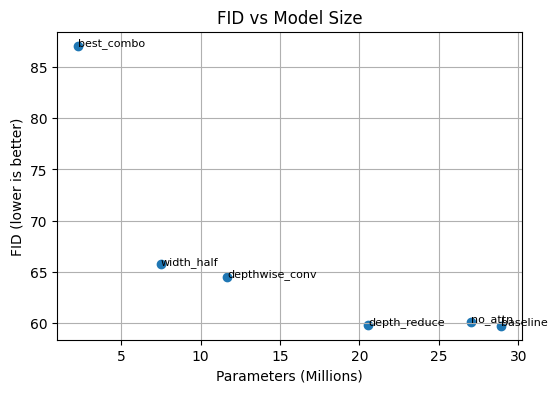

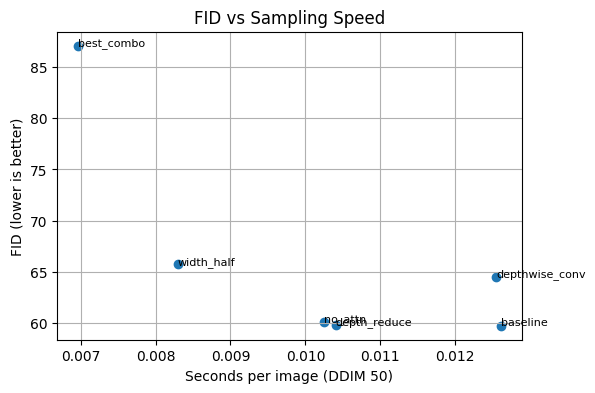

Saved plots to: /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/results


In [23]:
import matplotlib.pyplot as plt

# FID vs Params
plt.figure(figsize=(6,4))
plt.scatter(df_sorted["params_m"], df_sorted["fid_ddim"])
for _, r in df_sorted.iterrows():
    plt.text(r["params_m"], r["fid_ddim"], r["exp"], fontsize=8)
plt.xlabel("Parameters (Millions)")
plt.ylabel("FID (lower is better)")
plt.title("FID vs Model Size")
plt.grid(True)
plt.savefig(RESULT_DIR/"plot_fid_vs_params.png", dpi=200)
plt.show()

# FID vs Speed
plt.figure(figsize=(6,4))
plt.scatter(df_sorted["sec_per_img_ddim"], df_sorted["fid_ddim"])
for _, r in df_sorted.iterrows():
    plt.text(r["sec_per_img_ddim"], r["fid_ddim"], r["exp"], fontsize=8)
plt.xlabel("Seconds per image (DDIM 50)")
plt.ylabel("FID (lower is better)")
plt.title("FID vs Sampling Speed")
plt.grid(True)
plt.savefig(RESULT_DIR/"plot_fid_vs_speed.png", dpi=200)
plt.show()

print("Saved plots to:", RESULT_DIR)

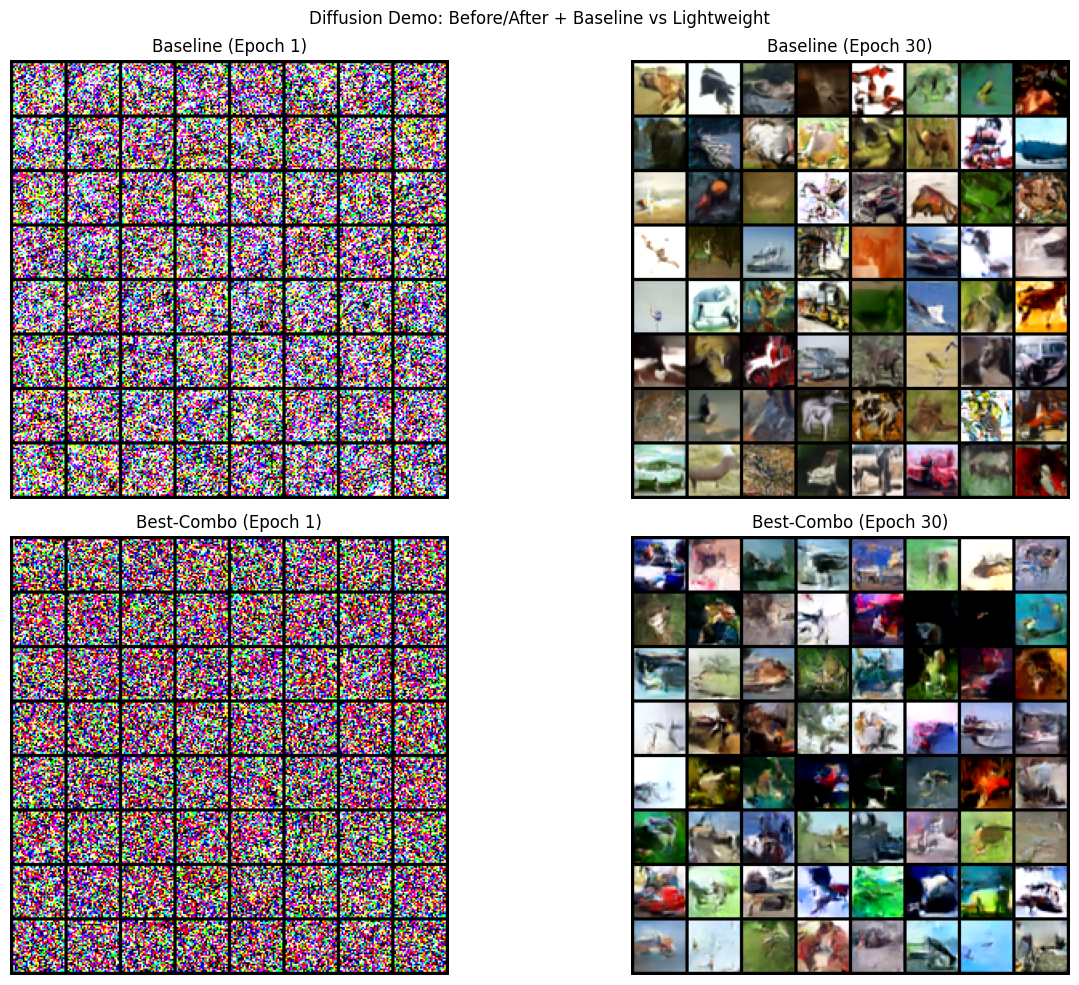

Saved: /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/results/teacher_demo_panel.png


In [24]:
from PIL import Image
import matplotlib.pyplot as plt

def teacher_demo_panel():
    base_last = EXPERIMENTS["baseline"]["epochs"]
    best_last = EXPERIMENTS["best_combo"]["epochs"]

    imgs = [
        (SAMPLE_DIR/"baseline_epoch1_ddim.png", "Baseline (Epoch 1)"),
        (SAMPLE_DIR/f"baseline_epoch{base_last}_ddim.png", f"Baseline (Epoch {base_last})"),
        (SAMPLE_DIR/"best_combo_epoch1_ddim.png", "Best-Combo (Epoch 1)"),
        (SAMPLE_DIR/f"best_combo_epoch{best_last}_ddim.png", f"Best-Combo (Epoch {best_last})"),
    ]

    loaded = [(Image.open(p), label) for p, label in imgs]

    plt.figure(figsize=(14,10))
    for i, (im, label) in enumerate(loaded):
        plt.subplot(2,2,i+1)
        plt.imshow(im)
        plt.axis("off")
        plt.title(label)

    plt.suptitle("Diffusion Demo: Before/After + Baseline vs Lightweight")
    out_path = RESULT_DIR/"teacher_demo_panel.png"
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.show()
    print("Saved:", out_path)

teacher_demo_panel()

We trained a baseline diffusion model (DDPM with a U-Net backbone) on CIFAR-10 and then performed an ablation study to understand how different “lightweight” changes affect (1) generation quality and (2) efficiency. For quality, we report FID (lower is better). For efficiency, we report seconds per generated image using DDIM sampling with 50 steps (lower is faster). We also report parameter count as a measure of model size.

Baseline

The baseline model contains 28.9M parameters and achieves FID = 59.76 with sampling speed 0.0126 s/img. Visual samples improve significantly from epoch 1 (pure noise) to epoch 30 (recognizable CIFAR-like objects), confirming the model learns a meaningful generative distribution.

Effect of individual lightweight modifications (Ablations)

Depth Reduction (depth_reduce)
Reducing the number of stages (channel multipliers from [1,2,2,2] to [1,2,2]) yields 20.6M parameters (≈28% smaller) while keeping FID almost unchanged (59.85 vs 59.76 baseline) and improving speed (0.0104 s/img).
Conclusion: Depth reduction provides the best quality–efficiency trade-off among all tested modifications.

Removing Attention (no_attn)
Disabling attention gives 27.0M parameters with FID = 60.11, very close to baseline, and faster sampling (0.01025 s/img).
Conclusion: Attention is not critical for this CIFAR-10 setup at this model scale; removing it gives a small efficiency gain with minimal quality loss.

Depthwise Convolutions (depthwise_conv)
Replacing standard convolutions with depthwise-separable convolutions reduces parameters to 11.7M, but quality drops (FID = 64.54) and sampling speed is almost the same as baseline (0.0125 s/img).
Conclusion: Depthwise convolutions significantly reduce capacity and harm generation quality, while not improving speed much in this implementation.

Width Reduction (width_half)
Halving width reduces parameters strongly to 7.49M and improves speed (0.00829 s/img), but FID worsens to 65.74.
Conclusion: Width reduction gives a strong efficiency gain at the cost of moderate quality degradation.

In [25]:
import json, pandas as pd

with open(RESULT_DIR/"summary_results.json") as f:
    results = json.load(f)

df = pd.DataFrame(results).sort_values("fid_ddim")
display(df)

print("Summary saved at:", RESULT_DIR/"summary_results.json")
print("Checkpoints folder:", CKPT_DIR)
print("Samples folder:", SAMPLE_DIR)
print("Results folder:", RESULT_DIR)

,exp,dataset,params_m,fid_ddim,sec_per_img_ddim,ddim_steps,use_attn,use_depthwise,width_mult,stages
0,baseline,CIFAR10,28.894595,59.760921,0.012608,50,NaN,NaN,NaN,NaN
2,depth_reduce,CIFAR10,20.562563,59.848145,0.010405,50,True,False,1.0,"[1, 2, 2]"
4,no_attn,CIFAR10,27.048835,60.106071,0.010247,50,False,False,1.0,"[1, 2, 2, 2]"
3,depthwise_conv,CIFAR10,11.674883,64.536728,0.012545,50,True,True,1.0,"[1, 2, 2, 2]"
1,width_half,CIFAR10,7.492419,65.737816,0.008293,50,True,False,0.5,"[1, 2, 2, 2]"
5,best_combo,CIFAR10,2.292739,87.070885,0.006965,50,False,True,0.5,"[1, 2, 2]"


Summary saved at: /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/results/summary_results.json
Checkpoints folder: /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/checkpoints
Samples folder: /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/samples
Results folder: /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/results
